
# Income Predictions - Logistic Regression (Timothy Manolias)

### The following program predicts whether an individual makes less than or greater than 50K dollars a year, based on 1994 U.S. census data and a logistic regression model.


## <font color='blue'>Imports Libraries and Data</font>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statistics
import warnings
import random

# Loads train data
train_data = pd.read_csv("income_train.csv")

# Loads test data
test_data = pd.read_csv("income_test.csv")

# Preserves pattern of randomness
random.seed(100)

In [2]:
train_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


The data contains entries with a value of `?`. Further analysis is performed below in order to evaluate the rows containing such entries.


## <font color='blue'>Data Preprocessing</font>

In [3]:
warnings.simplefilter("ignore", FutureWarning)

# Obtains # of rows with '?' for each column
ques_count = {}
for col in train_data.columns:
    try: ques_count[col] = train_data.loc[train_data[col] == '?'][col].value_counts()[0]
    except: pass

# Obtains # of rows where occupation and workclass == '?'
work_occ_nulls = train_data.loc[(train_data['occupation'] == '?') & (train_data['workclass'] == '?')].shape[0]

# Prints features with corresponding '?' count
print("'?' Count for Each Column")
print("--------------------------------------")

for key, value in ques_count.items():
    print(f"{key}:\t\t  {value:>5,} ({value*100/train_data.shape[0]:1.2}%)")

print(f"occupation & workclass: {work_occ_nulls:>7,} ({work_occ_nulls*100/train_data.shape[0]:1.2}%)")
print(f'\nTotal Entries in Data: \t{train_data.shape[0]:>7,}')
print("--------------------------------------")

'?' Count for Each Column
--------------------------------------
workclass:		  1,439 (5.5%)
occupation:		  1,444 (5.6%)
native_country:		    466 (1.8%)
occupation & workclass:   1,439 (5.5%)

Total Entries in Data: 	 26,000
--------------------------------------


As indicated above, nearly every entry of `occupation` with the value `?` also displays a value of `?` within `workclass`.

#### In order to interpret what to do with `?` values, I executed a different version of this notebook for three datasets:
- A dataset which keeps the '?' values as they originally appear. 
- A dataset which replaces all '?' values with the mode (most often) value of that column.
- A dataset which drops all rows with a '?' entry.

### Three Different Datasets
- Uncomment one dataset from below:

In [4]:
# Dataset 1: (Best Option)
# Keeping '?' Values as they originally appear

train_data = train_data
test_data = test_data

In [5]:
# # Dataset 2: 
# # Replacing '?' values with the mode (most often) value of given column

# for col in ['occupation', 'workclass', 'native_country']:
#     train_data.loc[train_data[col] == '?', col] = train_data[col].mode()[0]

In [6]:
# # Dataset 3: 
# # Drops rows that contain any value of '?'
# for col in test_data.columns:
#     train_data.drop(train_data[train_data[col] == '?'].index, inplace = True)
#     test_data.drop(test_data[test_data[col] == '?'].index, inplace = True)

#### The three datasets yield the following final test results:

In [7]:
three_datasets_eval = {'Dataset 1': {'Accuracy' : .681,
                                     'Precision': .300,
                                     'Recall'   : .496},
                       'Dataset 2': {'Accuracy' : .642,
                                     'Precision': .210,
                                     'Recall'   : .314},
                       'Dataset 3': {'Accuracy' : .801,
                                     'Precision': .000,
                                     'Recall'   : .000}}
three_datasets_eval = pd.DataFrame(three_datasets_eval)

In [8]:
three_datasets_eval

,Dataset 1,Dataset 2,Dataset 3
Accuracy,0.681,0.642,0.801
Precision,0.300,0.210,0.000
Recall,0.496,0.314,0.000


More than 5% of the data contains a column value of `?`. As displayed above, **keeping in the values as they originally appear allows for the best performance**. Therefore, preserving this data, as opposed to dropping 5% of the data, will result in the most optimal result going forward.

### Converts Dependent Variable (income) to Dummy Variables

In [9]:
# train_data
train_dummies = pd.get_dummies(train_data['income'])
if train_data['income'][1] not in [0, 1]:
    train_data = pd.concat((train_data, train_dummies['>50K']), axis=1)
    del train_data['income']
    train_data = train_data.rename(columns={">50K": "income"})

# test_data
test_dummies = pd.get_dummies(test_data['income'])
if test_data['income'][1] not in [0, 1]:
    test_data = pd.concat((test_data, test_dummies['>50K']), axis=1)
    del test_data['income']
    test_data = test_data.rename(columns={">50K": "income"})        

## <font color='blue'>Exploratory Data Analysis (Visualization)</font>

### Histograms of Numerical Features

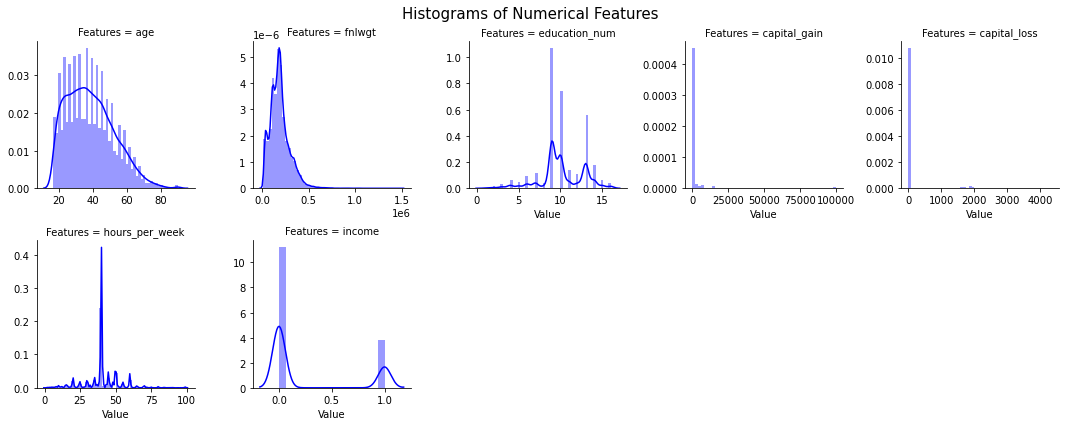

In [10]:
warnings.simplefilter("ignore", UserWarning)

numeric_features = train_data.select_dtypes(exclude=["object", "bool"])
numeric_features_stack = numeric_features.stack().reset_index().rename(columns = {"level_1":"Features", 0:"Value"})

grid = sns.FacetGrid(data=numeric_features_stack, col="Features",  col_wrap=5, sharex=False, sharey=False)
grid = grid.map(sns.distplot, "Value", color ='blue')

plt.subplots_adjust(top=0.9)
plt.suptitle("Histograms of Numerical Features", size=15);

**Evaluation of Histograms:**

- `age` seems to be the most normal distribution compared to the other numeric features.
- Most people within this dataset have a `highschool education` level or `college education` level (indicated by levels 9 & 10 in education_num).
- The `income` distribution indicates that there are many more people who make <=50K each year.
- Most people tend to work around `40 hours_per_week`.
- The `capital_gain` and `capital_loss` features are highly right-skewed. The capital_gain range is also significantly greater than the capital_loss range.

### Correlation Matrix

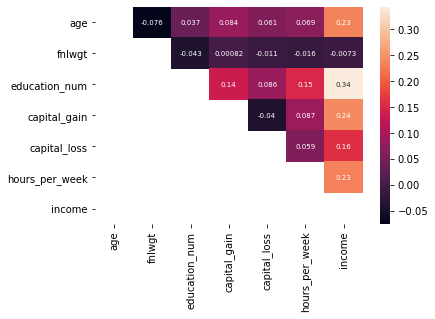

In [11]:
# Obtains each column in train data
corr_cols = [i for i in numeric_features.columns]

# Correlation Matrix
lower_corr_triangle = np.tril(train_data[corr_cols].corr())
sns.heatmap(train_data[corr_cols].corr(), annot=True, mask=lower_corr_triangle, annot_kws={'fontsize': 7});

According to the correlation matrix listed above, **none of the features are highly correlated**. We therefore do not have to account for multicollinearity.

### >50K Income Proportion by Education and Gender

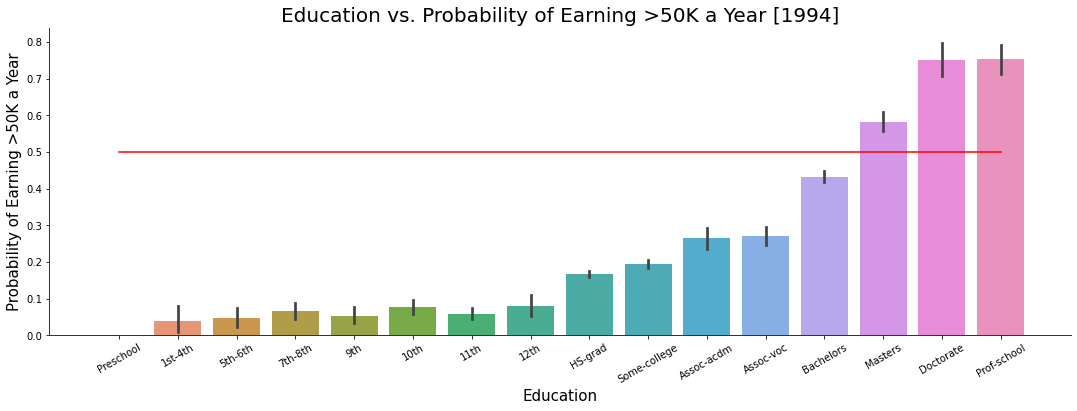

In [12]:
# Re-orders education group
x_axis_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college',
                'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Masters', 'Doctorate', 'Prof-school']

# Plots education vs. income graph
ax = sns.catplot(x="education", y="income", kind="bar", data=train_data, aspect=3, order=x_axis_order)
ax.set_xticklabels(rotation=30)

# Plots line where 50% of group makes >50K
x_coords, y_coords = [0,15], [0.5, 0.5]
plt.plot(x_coords, y_coords, 'r')

# Alters title and labels
plt.title('Education vs. Probability of Earning >50K a Year [1994]', size=20)
plt.ylabel('Probability of Earning >50K a Year', size=15)
plt.xlabel('Education', size=15);

- #### <font color='green'>* 50,000 dollars in 1994 is worth about 88,700 dollars in 2021*</font>

**Evaluation of 'Education vs. Income' Plot:**

- There seems to be an increase in probability of making >50K a year as education level increases (past high school).
- One can expect a salary >50K when pursuing a Master's Degree

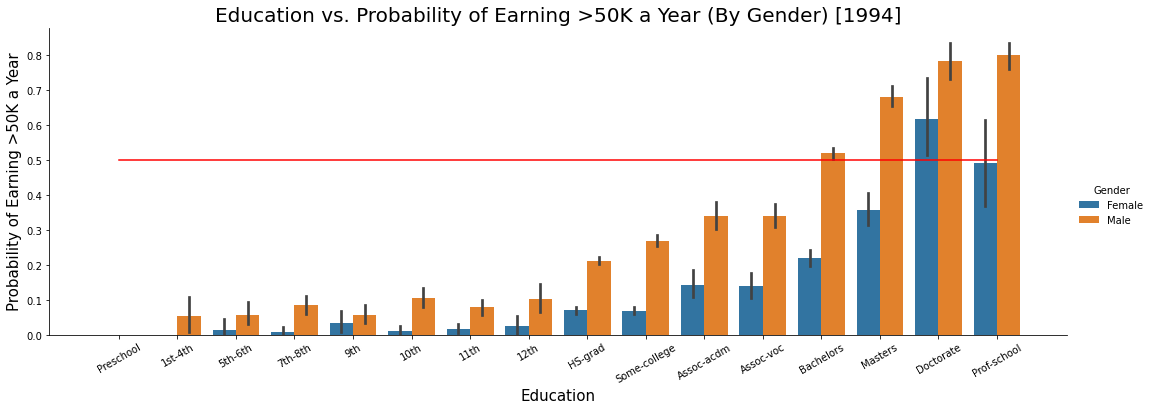

In [13]:
# Plots education vs. income by sex graph
ax = sns.catplot(x="education", y="income", hue="sex", kind="bar", data=train_data, aspect=3, order=x_axis_order)
ax.set_xticklabels(rotation=30)

# Plots line where 50% of group makes >50K
x_coords, y_coords = [0,15], [0.5, 0.5]
plt.plot(x_coords, y_coords, 'r')

# Alters title and labels
plt.title('Education vs. Probability of Earning >50K a Year (By Gender) [1994]', size=20)
plt.ylabel('Probability of Earning >50K a Year', size=15)
plt.xlabel('Education', size=15)
ax._legend.set_title('Gender');

- #### <font color='green'>* 50,000 dollars in 1994 is worth about 88,700 dollars in 2021*</font>

**Evaluation of 'Education vs. Income by Gender' Plot:**

- There is a clear `gap in probability of making >50K` a year between `men and women`.
- For `men`, atleast a `Bachelor's degree` is needed to expect >50K salary each year.
- For `women`, atleast a `Doctorate` is needed to expect >50K salary each year.

## <font color='blue'>Splits Data Into **Dependent** \& **Independent** Variables</font>

In [14]:
# Splits train and test data into X and y

# train_data
train_data_X = train_data.drop(['income'], axis=1)
train_data_y = train_data[['income']]

# test_data
test_data_X = test_data.drop(['income'], axis=1)
test_data_y = test_data[['income']]

## <font color='blue'>Standardization and One-Hot Encoding</font>

### Standardizes Continuous Features

In [15]:
from sklearn.preprocessing import StandardScaler

# Gets continuous variables
contin_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
contin_train = train_data_X[contin_cols]
contin_test = test_data_X[contin_cols]

In [16]:
# Standardizes continuous features

sc = StandardScaler()
for col in contin_cols:
    # X_train
    temp_train = np.array(contin_train[col]).reshape(-1, 1)
    train_data_X[col] = sc.fit_transform(temp_train)
    
    # X_test
    temp_test = np.array(contin_test[col]).reshape(-1, 1)
    test_data_X[col] = sc.fit_transform(temp_test)

### Converts Categorical Variables into Dummy Variables.

In [17]:
# Converts categorical variables into dummy variables

categ_cols = ['workclass', 'education', 'marital_status', 'occupation',
              'relationship', 'race', 'sex', 'native_country']

# X_train
categ_train = train_data_X[categ_cols]
categ_train = pd.get_dummies(categ_train)

# X_test
categ_test = test_data_X[categ_cols]
categ_test = pd.get_dummies(categ_test)

# Replaces old categorical columns with encoded columns
if categ_cols[0] in train_data_X.columns:
    # X_train
    train_data_X = train_data_X.drop(categ_cols, axis=1)
    train_data_X = pd.concat((train_data_X, categ_train), axis=1)
    
    # X_test
    test_data_X = test_data_X.drop(categ_cols, axis=1)
    test_data_X = pd.concat((test_data_X, categ_test), axis=1)

In [18]:
# Adds one-hot encoded columns from test set that were not in train set
for col in test_data_X.columns:
    if col not in train_data_X.columns:
        train_data_X[col] = 0
        
# Adds one-hot encoded columns from training set that were not in test set
for col in train_data_X.columns:
    if col not in test_data.columns:
        test_data_X[col] = 0

## <font color='blue'>Splits Training Data into Train and Validation Sets for Model Training</font>

In [19]:
X_train = train_data_X.iloc[:2800,:]
y_train = train_data_y.iloc[:2800,:]
X_val = train_data_X.iloc[2800:,:]
y_val = train_data_y.iloc[2800:,:]

## <font color='blue'>Logistic Regression</font>

### Builds Logistic Model

In [20]:
from sklearn.linear_model import LogisticRegression

# Creates and fits logistic regression model
mod = LogisticRegression(max_iter=1000)
mod.fit(X_train, y_train.values.ravel());

### Creates Precision, Recall & Accuracy Functions to Evaluate Performance

In [21]:
def precision(y, y_preds):
    """
    Returns precision, which is TP/(TP+FP).
    """
    tp = 0
    fp = 0
    for i in range(len(y_preds)):
        if y_preds[i] == 1:
            if y[i] == 1:
                tp += 1
            else:
                fp += 1
    
    return tp / (tp+fp) if tp+fp > 0 else 0

In [22]:
def recall(y, y_preds):
    """
    Returns recall, which is TP/(TP+FN).
    """
    tp = 0
    fn = 0
    for i in range(len(y_preds)):
        if y_preds[i] == 1 and y[i] == 1:
            tp += 1
        elif y[i] == 1 and y_preds[i] == 0:
            fn += 1
                
    return tp / (tp+fn)

In [23]:
def accuracy(y, y_preds):
    """
    Returns accuracy, which is (TP+TN)/(TP+FP+FN+TN).
    """
    tp, tn, fp, fn = (0, 0, 0, 0)
    
    for i in range(len(y_preds)):
        if y_preds[i] == 1 and y[i] == 1:
            tp += 1
        elif y_preds[i] == 1 and y[i] == 0:
            fp += 1
        elif y_preds[i] == 0 and y[i] == 1:
            fn += 1
        elif y_preds[i] == 0 and y[i] == 0:
            tn += 1
                
    return (tp + tn) / (tp + fp + fn + tn)

### Predicts Output for Validation Set

In [24]:
def threshold_pred(pred_probs, threshold_level=.465): #Optimal default based on evaluation of 200 threshold values
    """
    Returns new predicted value based on threshold value.
    """
    new_predictions = []
    for pred in pred_probs:
        if pred[1] >= threshold_level:
            new_predictions.append(1)
        else:
            new_predictions.append(0)
            
    return new_predictions

In [25]:
y_pred = threshold_pred(mod.predict_proba(X_val))
y_val = np.array([i[0] for i in y_val.values.tolist()])

### Evaluates Logistic Regression Performance on `train_data`

In [26]:
# Uses the predictions to calculate accuracy, precision, recall

train_precision = precision(y_val, y_pred)
print(f'Precision: {train_precision:.5f}')

train_recall = recall(y_val, y_pred)
print(f'Recall:    {train_recall:.5f}')

train_accuracy = accuracy(y_val, y_pred)
print(f'Accuracy:  {train_accuracy:.5f}')

Precision: 0.41452
Recall:    0.90723
Accuracy:  0.73056


### ROC Curve

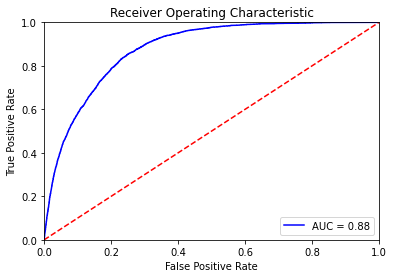

In [27]:
from sklearn.metrics import roc_curve
import sklearn.metrics as metrics

y_probs = mod.predict_proba(X_val)[:,1]
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_probs, pos_label=1)
roc_auc = metrics.auc(fpr, tpr)

# Plots AUC graph
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

## <font color='blue'>Tuning Hyperparameters of Logistic Regression Model</font>

In [28]:
def tune_logistic_model(c, p, X_train, y_train):
    """Builds logistic regression model based on
       given hyperparameters."""
    
    # Builds model
    mod = LogisticRegression(C=c, penalty=p, solver='liblinear').fit(X_train, y_train.values.ravel())

    return mod

In [29]:
def prediction_results(mod, y_val):
    """Prints precision, recall & accuracy values,
       based off logistic model's predictions."""
    
    # Predictions
    y_pred = threshold_pred(mod.predict_proba(X_val))
    
    # Prints accuracy, precision & recall
    print(f'Precision: {precision(y_val, y_pred):.5f}')
    print(f'Recall:    {recall(y_val, y_pred):.5f}')
    print(f'Accuracy:  {accuracy(y_val, y_pred):.5f}')

#### **Model 1**: Builds a logistic regression model with hyperparameter **'C' set to 0.1** and **penalty set to 'l1'**.

In [30]:
mod1 = tune_logistic_model(0.1, 'l1', X_train, y_train)
prediction_results(mod1, y_val)

Precision: 0.35698
Recall:    0.95450
Accuracy:  0.65397


#### **<font color='green'>Model 2</font>**: Builds a logistic regression model with <font color='green'>**hyperparameter 'C' set to 0.5** and **penalty set to 'l1'**.</font>

In [31]:
mod2 = tune_logistic_model(0.5, 'l1', X_train, y_train)
prediction_results(mod2, y_val)

Precision: 0.41386
Recall:    0.91251
Accuracy:  0.72944


#### **Model 3**: Builds a logistic regression model with hyperparameter **'C' set to 0.1** and **penalty set to 'l2'**.

In [32]:
mod3 = tune_logistic_model(0.1, 'l2', X_train, y_train)
prediction_results(mod3, y_val)

Precision: 0.35988
Recall:    0.95669
Accuracy:  0.65784


#### **Model 4**: Builds a logistic regression model with hyperparameter **'C' set to 0.5** and **penalty set to 'l2'**.

In [33]:
mod4 = tune_logistic_model(0.5, 'l2', X_train, y_train)
prediction_results(mod4, y_val)

Precision: 0.40092
Recall:    0.92240
Accuracy:  0.71453


### Best model out of the 4 listed above:

**Model 2**, with hyperparameter 'C' set to 0.5 and penalty set to 'l1', is the best based on its higher precision and accuracy values. Although model 2 has a slighty lower recall value than the other models, model 2's higher accuracy and precision outweigh the slight decrease in recall as compared to the other models. Therefore, <font color='green'>**model 2 is the best based on its higher accuracy and precision**</font>.

## <font color='blue'>Test Set Predictions</font>

#### Makes predictions on `test_data` using a logistic regression model with the best hyperparameters listed above.

In [34]:
# Sorts by columns
train_data_X = train_data_X.sort_index(axis=1)
test_data_X = test_data_X.sort_index(axis=1)

# Logistic regression
final_mod = mod2

In [35]:
# Predictions on test_data

test_pred = threshold_pred(final_mod.predict_proba(test_data_X))
test_val = np.array([i[0] for i in test_data_y.values.tolist()])

In [36]:
# Uses the predictions to calculate accuracy, precision, recall

test_precision = precision(test_val, test_pred)
print(f'Precision: {test_precision:.5f}')

test_recall = recall(test_val, test_pred)
print(f'Recall:    {test_recall:.5f}')

test_accuracy = accuracy(test_val, test_pred)
print(f'Accuracy:  {test_accuracy:.5f}')

Precision: 0.30000
Recall:    0.49603
Accuracy:  0.68145


## <font color='blue'>Results and Evaluation</font>

In [37]:
train_vs_test = {'Train Results': {'Precision': train_precision,
                                   'Recall'   : train_recall,
                                   'Accuracy' : train_accuracy},
                'Test Results'  : {'Precision': test_precision,
                                   'Recall'   : test_recall,
                                   'Accuracy' : test_accuracy}}

train_vs_test = pd.DataFrame(train_vs_test)

#### After training the logistic regression model with `train_data` and testing numerous hyperparameters, the following prediction results occurred `train_data` and `test_data`:

In [38]:
train_vs_test

,Train Results,Test Results
Precision,0.414524,0.300000
Recall,0.907232,0.496025
Accuracy,0.730560,0.681451


The **test set** predictions **yielded a lower performance** for precision and accuracy as compared to the train data predictions. Furthermore, the **recall value was significantly lower for the test set** as compared to the training set. This means that the logistic model falsely identified many >50K entries as <=50K entries.

The recall performance may be a result of overfitting. In order to diminish potential overfitting effects, it may be optimal in the future to:
- Re-train model with fewer features.
- Address income imbalance within the dataset itself.

### Best Features

In [39]:
# Calculates features with greatest impact on model
X_train_features = [col for col in X_train.columns]
coef_vals = [val for val in final_mod.coef_[0]]
features_coefs = [pair for pair in zip(X_train_features, coef_vals)]

# Sorts coefficients in descending order
features_coefs.sort(key=lambda tup: tup[1], reverse=True)
top5_pos, top5_neg = features_coefs[:5], features_coefs[-5:]

**Top 5 Features with Greatest <font color='green'>Positive Impact</font>** on Logistic Regression Model (Based on Coefficients)

In [40]:
[print(feature[0]) for feature in top5_pos];

capital_gain
marital_status_Married-civ-spouse
education_10th
relationship_Wife
education_num


**Top 5 Features with Greatest <font color='red'>Negative Impact</font>** on Logistic Regression Model (Based on Coefficients)

In [41]:
[print(feature[0]) for feature in top5_neg[::-1]];

relationship_Own-child
marital_status_Divorced
marital_status_Never-married
sex_Female
occupation_Farming-fishing


#### Evaluation of Features:
**Greatest <font color='green'>Positive</font> Features:**
- People with `greater capital gains` have a `higher probability` of making >50k a year.
- People with a `college degree` (education_10th) are `more likely to make >50k a year`.

**Greatest <font color='red'>Negative</font> Features:**
- People who `have a child` have a `lower probability` of making >50k a year.
- `Females` have a `lower probability of making >50k a year`, which is further supported by the gender breakdown chart in the exploratory analysis portion.

## <font color='blue'>Overall Performance</font>
#### Based on the performance of the test dataset, the model correctly predicts whether an individual makes less than or greater than 50K a year **<font color='green'>68.1%</font>** of the time.

#### Given these results, having greater capital gains and a college degree increases one's probability of making >50K dollars a year. Also, having a child decreases ones probability of making >50K a year. Furthermore, the data demostrates that females also had a lower probability of making >50K dollars in 1994.